In [1]:
# Làm nốt 90 xem weight sử dụng thế nào trong fold và full
# Dấu ; bảo Jupyter: “đừng show output”

# 💡 Gap lớn = overfit / shift / tail noisy
# 💡 Gap nhỏ nhưng val_loss tệ = underfit
import pandas as pd
import numpy as np
import sys
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Eval
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import mean_pinball_loss

# CV
# from sklearn.model_selection import cross_val_score
# from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.ensemble import GradientBoostingRegressor
# from xgboost import XGBRegressor
# from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor, CatBoostClassifier
# from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_pinball_loss,make_scorer
# from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Hyper tuning
from skopt import BayesSearchCV
from sklearn.model_selection import RandomizedSearchCV
# Training
from sklearn.model_selection import KFold

# Calibrate
from sklearn.linear_model import QuantileRegressor

print(sys.executable)
print(sys.version)

# Không có copy khi sao bản mới, b = a copy mỗi con trỏ, đường dẫn tới mảng đó

C:\Users\trieu\miniconda3\envs\PJ1_310\Scripts\python.exe
3.10.2 (tags/v3.10.2:a58ebcc, Jan 17 2022, 14:12:15) [MSC v.1929 64 bit (AMD64)]


In [2]:
# Vùng flat
# improve_rate=(Lt−1-Lt)/Lt-1
# < 1% → bắt đầu nghi ngờ plateau

# < 0.5% → gần như flat

# < 0.1% → flat rõ ràng, tối ưu thêm không đáng

# | gap ratio | Ý nghĩa                     |
# | --------- | --------------------------- |
# | ≈ 0       | train ≈ val → fit ổn        |
# | 0.1 – 0.3 | overfit nhẹ, chấp nhận được |
# | 0.3 – 0.6 | overfit rõ ràng             |
# | > 1.0     | overfit nặng                |


In [3]:
def eval_quantile_model(model,alpha,len_train_sample,
                        X_train,y_train,
                        X_val, y_val,
                       lam=0.3):
    pred_train = np.expm1(model.predict(X_train))
    pred_val = np.expm1(model.predict(X_val))

    train_loss= mean_pinball_loss(y_train, pred_train, alpha = alpha)
    train_rel_loss = train_loss/np.mean(y_train) # do chia với y => rel
    train_cover = np.mean(y_train <= pred_train)

    val_loss = mean_pinball_loss(y_val, pred_val, alpha = alpha)
    val_rel_loss = val_loss/np.mean(y_train) # do chia với y => rel
    val_cover = np.mean(y_val <= pred_val)

    mae = np.mean(np.abs(y_val - pred_val))
    rmse = np.sqrt(np.mean((y_val - pred_val)**2))

    
    rel_gap = val_rel_loss - train_rel_loss #model với data mới
    
    gap_ratio = rel_gap / train_rel_loss
    overfit_score = rel_gap * np.sqrt(len_train_sample) #(len_train_sample ** 0.5)
    
    total_score = val_rel_loss + lam * max(rel_gap,0)
    
    print(pd.DataFrame({
    'quantile:': f"{alpha*100}",
    'train loss': [train_rel_loss],
    'val loss': [val_rel_loss],#⭐⭐⭐
    'train_cover:':[train_cover],
    'val_cover:':[val_cover],#⭐⭐⭐
    'rel_gap':[rel_gap],#⭐⭐⭐ gap tương đối là 1-50%, tuyệt đối:trừ thẳng giá trị thật loss 1-20%
    'gap_ratio':[gap_ratio],
    # 'overfit score':[overfit_score],
    'total_score':[total_score],#⭐⭐⭐
    'Mae':[mae],
    'rmse':[rmse]
    # Các metric khác đều là phụ
    }))
    

In [4]:
# # # # phạt overfit, không phạt underfit khi gap âm
# # # | λ nhỏ                | λ lớn              |
# # # | -------------------- | ------------------ |
# # # | Ít phạt overfit      | Phạt overfit mạnh  |
# # # | Chọn model loss thấp | Chọn model ổn định |
# # # | Dễ overfit           | Dễ underfit        |

# # | Mức độ           | λ khuyên dùng |
# # | ---------------- | ------------- |
# # | Nhẹ              | 0.05          |
# # | Vừa (chuẩn)      | **0.1 – 0.3** |
# # | Rất ghét overfit | 0.5 – 1.0     |
# # dùng mean 1 tập chia không sẽ so sánh hai metric ở hai thang đo khác nhau.

# 7. Khi nào mới chia theo mean của từng tập?

# Chỉ khi:

# bạn báo cáo metric độc lập

# không dùng để tính gap

# ví dụ: báo cáo MAE% trên test

In [5]:
def eval_quantile_test(model, alpha, X_test, y_test, y_train):
    pred_test = np.expm1(model.predict(X_test))

    test_loss = mean_pinball_loss(y_test, pred_test, alpha=alpha)
    test_rel_loss = test_loss / np.mean(y_train)
    test_cover = np.mean(y_test <= pred_test)

    mae = np.mean(np.abs(y_test - pred_test))
    rmse = np.sqrt(np.mean((y_test - pred_test)**2))

    print(pd.DataFrame({
        'quantile': [f"{alpha*100}"],
        'test_loss': [test_rel_loss],
        'test_cover': [test_cover],
        'mae': [mae],
        'rmse': [rmse]
    }))

In [6]:
# def eval_model_final(model, alpha, X_train, X_test, y_train, y_test,inverse_formula=None):
#     pred_train = model.predict(X_train)
#     pred_test = model.predict(X_test)
#     if inverse_formula is not None:
#         pred_train = inverse_formula(pred_train)
#         pred_test = inverse_formula(pred_test)
    
#     rel_loss_train = mean_pinball_loss(y_train, pred_train, alpha = alpha)/np.mean(y_train)
#     train_cover = np.mean(y_train <= pred_train)

#     rel_loss_test = mean_pinball_loss(y_test, pred_test, alpha = alpha)/np.mean(y_test) # do chia với y => rel
#     test_cover = np.mean(y_test <= pred_test)
#     mae = np.mean(np.abs(y_test - pred_test)) #mean absolute error
#     print(pd.DataFrame({
#     'quantile:': f"{alpha*100}",
#     'train loss': [rel_loss_train],
#     'train_cover:':[train_cover],
#     'test loss': [rel_loss_test],
#     'test_cover:':[test_cover],
#     'rel loss gap':[rel_loss_gap],
#     'MAE':[mea]
#     }))

In [7]:
# Tạo list bên ngoài để giữ lại giá trị trong vòng lặp
# return {
#     "oof": oof_pred,
#     "models": models,
#     "val_idx": val_indices
# }
def train_quantile_model(X, y, alpha, params, n_splits=5, random_state=42):
    kf = KFold(n_splits=n_splits, shuffle = True, random_state= random_state)
    val_indices = []
    oof_pred = np.zeros(len(y))
    models = []

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model = CatBoostRegressor(
            random_seed = random_state +fold,
            # verbose = False,
            **params
        )
        model.fit(X_tr, y_tr)
        pred_val = model.predict(X_val)
        oof_pred[val_idx] = pred_val
        models.append(model)
        val_indices.append(val_idx)
        print(f"Fold {fold} done for q{int(alpha*100)}")
    return models,oof_pred, val_indices

In [8]:
# def evaluation_fold_model(models,X,y, cv=5, lambda_risk= 0.05):
#     result={}
#     for name, model in models.items():
#         # item trả về key, value
#         scores = cross_val_score(model,X,y, cv=cv, scoring=pinball_scorer)/ np.mean(y)
#         # Chọn metric trước không lại phải quay lại
#         mean_score = scores.mean()
#         std_score = scores.std()
#         risk_adjusted = mean_score + lambda_risk * std_score
#         result[name] = {
#             'mean': mean_score,
#             'std': std_score,
#             'risk_adjusted': risk_adjusted
#         }
#         # Cách gọi value = Ghi đè key lên
#     return result

In [9]:
df_processed = pd.read_csv('../../data/processed/df_processed.csv', index_col=0) #index_col=0 bỏ index cũ (cột unnamed:0)
df_processed

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,population_per_household,...,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,income_level_poor,income_level_mid,income_level_upper-mid,income_level_rich,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,6.984127,2.555556,...,False,False,False,True,False,False,False,False,True,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,6.238137,2.109842,...,False,False,False,True,False,False,False,True,False,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,8.288136,2.802260,...,False,False,False,True,False,False,False,False,True,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,5.817352,2.547945,...,False,False,False,True,False,False,False,False,True,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,6.281853,2.181467,...,False,False,False,True,False,False,False,True,False,342200.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,5.045455,2.560606,...,False,True,False,False,False,False,True,False,False,78100.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,6.114035,3.122807,...,False,True,False,False,False,False,False,True,False,77100.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,5.205543,2.325635,...,False,True,False,False,False,True,False,False,False,92300.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,5.329513,2.123209,...,False,True,False,False,False,False,True,False,False,84700.0


In [10]:
y= df_processed.loc[:,'median_house_value']
y

0        452600.0
1        358500.0
2        352100.0
3        341300.0
4        342200.0
           ...   
20635     78100.0
20636     77100.0
20637     92300.0
20638     84700.0
20639     89400.0
Name: median_house_value, Length: 20640, dtype: float64

In [11]:
num_cols= df_processed.drop(df_processed.columns[[-4,-3]], axis=1)
X= df_processed.drop('median_house_value', axis=1)
X

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,population_per_household,income_per_person,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,income_level_poor,income_level_mid,income_level_upper-mid,income_level_rich
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,6.984127,2.555556,0.025855,False,False,False,True,False,False,False,False,True
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,6.238137,2.109842,0.003457,False,False,False,True,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,8.288136,2.802260,0.014632,False,False,False,True,False,False,False,False,True
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,5.817352,2.547945,0.010113,False,False,False,True,False,False,False,False,True
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,6.281853,2.181467,0.006807,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,5.045455,2.560606,0.001847,False,True,False,False,False,False,True,False,False
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,6.114035,3.122807,0.007182,False,True,False,False,False,False,False,True,False
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,5.205543,2.325635,0.001688,False,True,False,False,False,True,False,False,False
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,5.329513,2.123209,0.002520,False,True,False,False,False,False,True,False,False


In [12]:
# Sửa lỗi LightGBM
X.columns = X.columns.str.replace(r"[\[\]<>?]", "_", regex=True)
X.columns = [c.replace(" ", "_") for c in X.columns]
X

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,population_per_household,income_per_person,ocean_proximity__1H_OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR_BAY,ocean_proximity_NEAR_OCEAN,income_level_poor,income_level_mid,income_level_upper-mid,income_level_rich
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,6.984127,2.555556,0.025855,False,False,False,True,False,False,False,False,True
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,6.238137,2.109842,0.003457,False,False,False,True,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,8.288136,2.802260,0.014632,False,False,False,True,False,False,False,False,True
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,5.817352,2.547945,0.010113,False,False,False,True,False,False,False,False,True
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,6.281853,2.181467,0.006807,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,5.045455,2.560606,0.001847,False,True,False,False,False,False,True,False,False
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,6.114035,3.122807,0.007182,False,True,False,False,False,False,False,True,False
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,5.205543,2.325635,0.001688,False,True,False,False,False,True,False,False,False
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,5.329513,2.123209,0.002520,False,True,False,False,False,False,True,False,False


In [13]:
# Split
# Mỗi cặp x, y gắn liền với 1 tune trong pipeline, tránh pipeline leak, mỗi 1 phiên bản của 1 val dùng mấy lần
# cách 1 chia 4 val
# 2 evaluate duy nhất lần cuối để tuning cả 1 tập, 
# Để tránh chia val làm 4 => eval ở cuối, tất cả pipeline đến gate chỉ được evaluate khi nào xong
# \ Tạo thêm sample từ model đã train (khả năn overfit), lúc đó các hàm val của model trước vẫn không được liên quan đến sau
# \ Dùng fold cho cả 3 => kết quả fold model không nhìn thấy kết quả, => y_train sử dụng để evaluate lại model được
# fold:q10 q50 q90 eval: y_train
# gate 90: eval val1
# tail val 2
# Leak chỉ không xảy ra với y trên tập mà nó chưa từng biết, evaluate(view và tuning) đi kèm với tuning leak trong cả pipeline và model độc lập cần để ý

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size =0.3, random_state = 42)
X_test.reset_index(inplace= True, drop=True)
y_test.reset_index(inplace= True, drop=True)
# tránh pipeline leak

In [15]:
# Chia tập test thay vì train cho đều
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size =0.5, random_state = 42)

# X_val, X_full_val, y_val, y_full_val = train_test_split(X_val, y_val, test_size =0.2, random_state = 42)

# X_gate_val, X_tail_val, y_gate_val, y_tail_val = train_test_split(X_val, y_val, test_size =0.5, random_state = 42)


# X_train.reset_index(inplace= True, drop=True)
# y_train.reset_index(inplace= True, drop=True)

# X_val.reset_index(inplace= True, drop=True)
# y_val.reset_index(inplace= True, drop=True)


# X_full_val.reset_index(inplace= True, drop=True)
# y_full_val.reset_index(inplace= True, drop=True)

# X_gate_val.reset_index(inplace= True, drop=True)
# y_gate_val.reset_index(inplace= True, drop=True)

# X_tail_val.reset_index(inplace= True, drop=True)
# y_tail_val.reset_index(inplace= True, drop=True)


# # ⭐ Fold dùng X_val riêng

In [16]:
y_train_log = np.log1p(y_train)
y_test_log= np.log1p(y_test)

y_val_log = np.log1p(y_val)

# y_full_val_log =  np.log1p(y_full_val)
# y_gate_val_log = np.log1p(y_gate_val)
# y_tail_val_log = np.log1p(y_tail_val)

In [17]:
# from sklearn.preprocessing import StandardScaler
# scaler_x = StandardScaler()
# # num_cols = x_train.select_dtypes(include=['int64','float64']).columns
# # x_train[num_cols] = scaler_x.fit_transform(x_train[num_cols])
# # x_test[num_cols] = scaler_x.transform(x_test[num_cols])
# x_train = scaler_x.fit_transform(x_train)
# x_train

In [18]:
# scaler_y = StandardScaler()
# y_train_val= y_train.values.reshape(-1,1)
# y_test_val = y_test.values.reshape(-1,1)

# y_train_scaled = scaler_y.fit_transform(y_train_val)
# y_test_scaled = scaler_y.transform(y_test_val)
# y_train_scaled

In [19]:
# Chọn mô hình CV

# Các bước cần làm: chọn metric- dựa vào data gốc, outlier, 2 tính CV
# Sử dụng cho lần sau RandomizedSearchCV 
# !pip install xgboost
# !pip install lightgbm

# ⭐⭐⭐ Chọn metric trước khi tính CV
# Xem phân phối y:
# Nếu gần Gaussian, ít outlier → trung bình (MSE/MAE) OK.
# Nếu nặng về outlier → quan tâm quantile (Pinball loss) hoặc biến đổi log/winsorize.
# Xác định mục tiêu thực tế:
# Bạn có cần dự đoán “giá trị trung bình” hay “khoảng tin cậy cho 80% dân số”?
# Nếu cần khoảng tin cậy → Pinball loss + quantile model.


pinball_scorer = make_scorer(mean_pinball_loss, alpha=0.1)

# models= {
#     'lr': LinearRegression(),
#     'ridge': make_pipeline(StandardScaler(),Ridge(max_iter=10_000)),
#     'lasso': make_pipeline(StandardScaler(),Lasso(max_iter=10_000)),
#     'elasnet': make_pipeline(StandardScaler(),ElasticNet(max_iter=10_000)),
#     'dtree': DecisionTreeRegressor(random_state=42),
#     'rf':RandomForestRegressor(random_state=42),
#     'gbr':GradientBoostingRegressor(random_state=42),
#     'xg':XGBRegressor(random_state=42),
#     'lgbm':LGBMRegressor(verbose=-1,random_state=42),
#     'cb': CatBoostRegressor(random_state=42,verbose=0),
#     'mlp': make_pipeline(
#         StandardScaler(),
#         MLPRegressor(hidden_layer_sizes=(128,64),
#                      max_iter=5_000,
#                      random_state=42,
#                      solver='adam', early_stopping=True)
#                     )
    # Input để giới hạn log
        # }
# models_cv = evaluation_model(models, X, y)

# Risk_adjustment =>với loss trung bình cộng thêm rủi ro thì mô hình nào là an toàn nhất

# Thêm _ cho dễ nhìn khi nhập số

# Chỉ 3 cái cần max_iter: Ridge – Lasso – ElasticNet là có vòng lặp nên cần thêm max_iter(max vòng lặp)

# Chạy lâu => lưu lại giá trị

# Chưa chia test và train kết quả không khác chia rồi
# mean càng nhỏ => loss nhỏ, tốt
# risk_adjusted = mean − λ·std → cũng càng nhỏ càng tốt

# fold các phần được chia nhỏ

In [20]:
# models_cv = pd.DataFrame(models_cv)
# # models_cv.to_csv('cv_score/cv_score_3.csv')
# models_cv

In [21]:

alpha = 0.1

# Model base - mô hình dò, kèm theo tham số cố định

cat = CatBoostRegressor(
    loss_function=f'Quantile:alpha={alpha}',
    verbose=0,
    random_state=42,
    allow_writing_files=False
)
# Tạo khoảng param tìm tron
# Không nên để iterations quá rộng
param_space = {
    'depth': (3, 8),
    'learning_rate': (0.01, 0.15, 'log-uniform'),
    'l2_leaf_reg': (1, 10),
    'iterations': (800, 2000),  # giảm range
    'subsample': (0.6, 1.0),
    'random_strength': (0.1, 10.0, 'log-uniform')
}

# Pinball scorer (BayesSearch sẽ maximize -> phải để negative)
pinball_scorer = make_scorer(
    mean_pinball_loss,
    alpha=alpha,
    greater_is_better=False
)

cv = KFold(n_splits=3, shuffle=True, random_state=42)

bayes_search = BayesSearchCV(
    estimator=cat,
    search_spaces=param_space,
    n_iter=40,  
    cv=cv,
    scoring=pinball_scorer,
    random_state=42,
    n_jobs=-1,
    refit=True
)
# Tính => fold val, tính điểm CV(tối ưu loss), tuning lại

# bayes_search.fit(
#     X_train,
#     y_train,
#     eval_set=[(X_train, y_train)],   
#     early_stopping_rounds=100
# ) #⭐⭐⭐⭐⭐⭐


# best_params = bayes_search.best_params_

# print(
#     "q10 = CatBoostRegressor(\n" +
#     ",\n".join([f"    {k}={repr(v)}" for k, v in best_params.items()]) +
#     "\n)"
# )


In [22]:
# q10 = CatBoostRegressor(
#     depth=4,
#     iterations=500,
#     l2_leaf_reg=9, # phạt
#     learning_rate=0.038275576007207185,
#     loss_function="Quantile:alpha=0.1",
#     random_strength=0.16620612512184482,
#     subsample=0.8344892090454218,
#     verbose=False
#     )

q10 = CatBoostRegressor(
    depth=5,
    iterations=1200,
    l2_leaf_reg=10,
    learning_rate=0.023097713370147255,
    random_strength=3.8536036170950547,
    subsample=0.9363719973911651,
    loss_function="Quantile:alpha=0.1",
    eval_metric="Quantile:alpha=0.1",
    od_type="IncToDec",
    od_wait=500, #early stop 
    verbose=100
    )

# Vùng flat
q10.fit(X_train,
        y_train_log,
       eval_set=(X_val,y_val_log)
       )

0:	learn: 0.1006314	test: 0.1022207	best: 0.1022207 (0)	total: 137ms	remaining: 2m 43s
100:	learn: 0.0539905	test: 0.0543455	best: 0.0543455 (100)	total: 303ms	remaining: 3.3s
200:	learn: 0.0464339	test: 0.0472776	best: 0.0472776 (200)	total: 476ms	remaining: 2.37s
300:	learn: 0.0435777	test: 0.0445571	best: 0.0445571 (300)	total: 652ms	remaining: 1.95s
400:	learn: 0.0415659	test: 0.0427912	best: 0.0427911 (399)	total: 824ms	remaining: 1.64s
500:	learn: 0.0395409	test: 0.0410920	best: 0.0410920 (500)	total: 998ms	remaining: 1.39s
600:	learn: 0.0376248	test: 0.0394183	best: 0.0394183 (600)	total: 1.18s	remaining: 1.17s
700:	learn: 0.0363187	test: 0.0385005	best: 0.0385005 (700)	total: 1.35s	remaining: 962ms
800:	learn: 0.0353818	test: 0.0378881	best: 0.0378881 (800)	total: 1.52s	remaining: 759ms
900:	learn: 0.0345264	test: 0.0373904	best: 0.0373904 (900)	total: 1.69s	remaining: 562ms
1000:	learn: 0.0337451	test: 0.0369462	best: 0.0369462 (1000)	total: 1.88s	remaining: 373ms
1100:	learn:

In [23]:
eval_quantile_model(q10, 0.1, len(y_train), X_train, y_train, X_val, y_val, lam= 0.1)

  quantile:  train loss  val loss  train_cover:  val_cover:   rel_gap  \
0      10.0    0.027972   0.03009      0.097799    0.121447  0.002118   

   gap_ratio  total_score           Mae          rmse  
0   0.075714     0.030302  50509.526474  74512.348858  


In [24]:
eval_quantile_test(q10, 0.1, X_test, y_test, y_train)

  quantile  test_loss  test_cover           mae         rmse
0     10.0   0.031049    0.107881  52228.170423  77411.96222


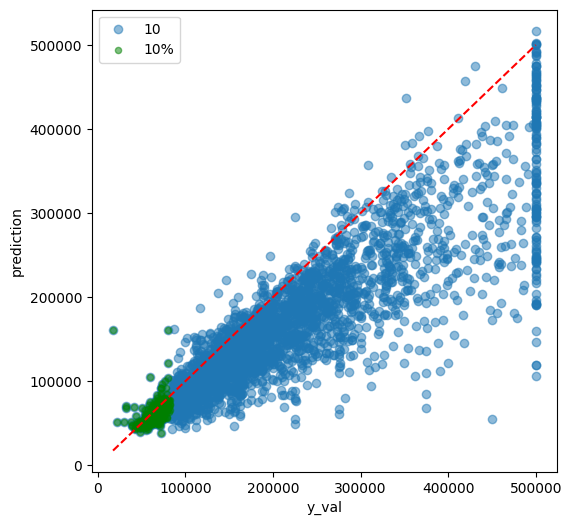

In [25]:
mask_q10 = y_val <= y_val.quantile(0.1)
min_y = y_val.min()
max_y = y_val.max()
pred_q10_val = np.expm1(q10.predict(X_val))
plt.figure(figsize=(6,6))
plt.scatter(x=y_val,y=pred_q10_val,alpha=0.5,label='10')

plt.scatter(x=y_val[mask_q10],y=pred_q10_val[mask_q10],color='green',alpha=0.5, label='10%', s=20)


plt.plot([min_y, max_y], [min_y, max_y], 'r--')
plt.xlabel("y_val")
plt.ylabel("prediction")
plt.legend() #để ra label

In [26]:

alpha = 0.5

cat = CatBoostRegressor(
    loss_function=f'Quantile:alpha={alpha}',
    verbose=0,
    random_state=42,
    allow_writing_files=False
)

param_space = {
    'depth': (3, 8),
    'learning_rate': (0.01, 0.15, 'log-uniform'),
    'l2_leaf_reg': (1, 10),
    'iterations': (800, 2000),  # giảm range
    'subsample': (0.6, 1.0),
    'random_strength': (0.1, 10.0, 'log-uniform')
}

pinball_scorer = make_scorer(
    mean_pinball_loss,
    alpha=alpha,
    greater_is_better=False
)

cv = KFold(n_splits=3, shuffle=True, random_state=42)

bayes_search = BayesSearchCV(
    estimator=cat,
    search_spaces=param_space,
    n_iter=40,  
    cv=cv,
    scoring=pinball_scorer,
    random_state=42,
    n_jobs=-1,
    refit=True
)

# bayes_search.fit(
#     X_train,
#     y_train,
#     eval_set=[(X_train, y_train)],   
#     early_stopping_rounds=100
# )


# best_params = bayes_search.best_params_

# print(
#     "q50 = CatBoostRegressor(\n" +
#     ",\n".join([f"    {k}={repr(v)}" for k, v in best_params.items()]) +
#     "\n)"
# )
# q50 = CatBoostRegressor(
#     depth=6,
#     iterations=1681,
#     l2_leaf_reg=1,
#     learning_rate=0.08773080035399637,
#     random_strength=0.42971682636413133,
#     subsample=1.0
# )


In [27]:
# Cũ
# q50 = CatBoostRegressor(
#     depth = 4,
#     iterations=1846,
#     l2_leaf_reg=6, # phạt
#     learning_rate=0.042,
#     random_strength= 0.4279818915661956,
#     loss_function="Quantile:alpha=0.5",
#     subsample= 1.0,
#     verbose=False
#     )
# q50.fit(X_train,y_train_log)

# q50 = CatBoostRegressor(
#     depth=6,
#     iterations=3848,
#     l2_leaf_reg=10,
#     learning_rate=0.05337833670465932,
#     random_strength=0.7015193476455812,
#     subsample=1.0,
#     loss_function="Quantile:alpha=0.5",
#     eval_metric="Quantile:alpha=0.5",
#     od_type="IncToDec",
#     od_wait=50, #early stop 
#     verbose=100
#     )

q50 = CatBoostRegressor(
    depth=6,
    iterations=600, # từ 600 bắt đầu flat(cải thiện 0.11% loss
    l2_leaf_reg=1,
    learning_rate=0.08773080035399637,
    random_strength=0.42971682636413133,
    subsample=1.0,
    loss_function="Quantile:alpha=0.5",
    eval_metric="Quantile:alpha=0.5",
    od_type="IncToDec",
    od_wait=50, #early stop 
    verbose=50
)

    
q50.fit(X_train,y_train_log,
       eval_set= (X_val,y_val_log))

# Cần tuning theo hướng parameter nhỏ nhất dủ chạm vùng phẳng( loss cải thiện ít)
# Gap thấp mô hình gặp data mới ổn định hơn

# improve_rate=(Lt−1-Lt)/Lt-1
# < 1% → bắt đầu nghi ngờ plateau

# < 0.5% → gần như flat

# < 0.1% → flat rõ ràng, tối ưu thêm không đáng

0:	learn: 0.2168748	test: 0.2167762	best: 0.2167762 (0)	total: 3.08ms	remaining: 1.84s
50:	learn: 0.0942421	test: 0.0942560	best: 0.0942560 (50)	total: 104ms	remaining: 1.12s
100:	learn: 0.0841024	test: 0.0854186	best: 0.0854186 (100)	total: 213ms	remaining: 1.05s
150:	learn: 0.0784331	test: 0.0811778	best: 0.0811778 (150)	total: 320ms	remaining: 950ms
200:	learn: 0.0745393	test: 0.0788551	best: 0.0788551 (200)	total: 438ms	remaining: 869ms
250:	learn: 0.0717267	test: 0.0773604	best: 0.0773604 (250)	total: 544ms	remaining: 756ms
300:	learn: 0.0693854	test: 0.0762523	best: 0.0762523 (300)	total: 651ms	remaining: 647ms
350:	learn: 0.0674205	test: 0.0753655	best: 0.0753655 (350)	total: 774ms	remaining: 549ms
400:	learn: 0.0657466	test: 0.0746311	best: 0.0746311 (400)	total: 895ms	remaining: 444ms
450:	learn: 0.0644482	test: 0.0740398	best: 0.0740398 (450)	total: 1.01s	remaining: 333ms
500:	learn: 0.0633035	test: 0.0736595	best: 0.0736595 (500)	total: 1.11s	remaining: 220ms
550:	learn: 0.0

In [28]:
eval_quantile_model(q50, 0.5, len(y_train), X_train, y_train, X_val, y_val, lam= 0.1)

# Overfit Score (%),Đánh giá,Hành động
# < 10%,Rất tốt,Mô hình có tính tổng quát hóa cao.
# 10% - 20%,Chấp nhận được,Đây là mức phổ biến trong các bài toán thực tế.
# 20% - 50%,Cao (Overfitting),Cần bắt đầu dùng các biện pháp chế tài (Regularization).
# > 50%,Rất nặng,"Mô hình đang ""học thuộc lòng"". Kết quả trên dữ liệu mới sẽ không đáng tin."

  quantile:  train loss  val loss  train_cover:  val_cover:   rel_gap  \
0      50.0    0.059202  0.069024      0.498616    0.519057  0.009822   

   gap_ratio  total_score           Mae          rmse  
0   0.165908     0.070006  28565.404628  45378.936494  


In [29]:
eval_quantile_test(q50, 0.5, X_test, y_test, y_train)

  quantile  test_loss  test_cover           mae          rmse
0     50.0    0.07313    0.494832  30264.883723  48928.808376


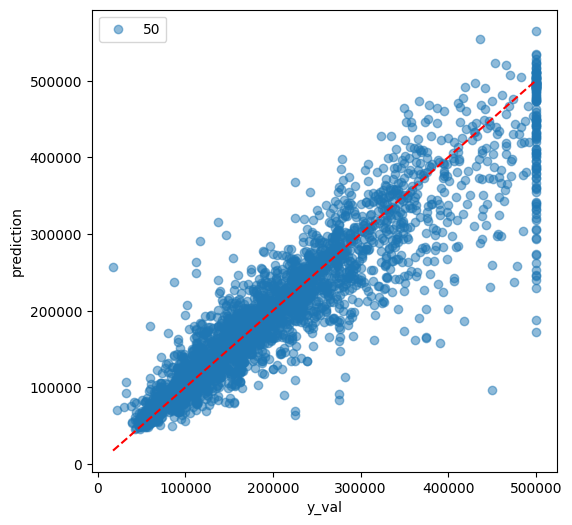

In [30]:
min_y = y_val.min()
max_y = y_val.max()
pred_q50_val = np.expm1(q50.predict(X_val))
plt.figure(figsize=(6,6))
plt.scatter(x=y_val,y=pred_q50_val,alpha=0.5,label='50')
plt.plot([min_y, max_y], [min_y, max_y], 'r--')
plt.xlabel("y_val")
plt.ylabel("prediction")
plt.legend() #để ra label

In [31]:

alpha = 0.9


cat = CatBoostRegressor(
    loss_function=f'Quantile:alpha={alpha}',
    verbose=0,
    random_state=42,
    allow_writing_files=False
)
param_space = {
    'depth': (3, 8),
    'learning_rate': (0.01, 0.15, 'log-uniform'),
    'l2_leaf_reg': (1, 10),
    'iterations': (500, 2000),  # giảm range
    'subsample': (0.6, 1.0),
    'random_strength': (0.1, 10.0, 'log-uniform')
}

pinball_scorer = make_scorer(
    mean_pinball_loss,
    alpha=alpha,
    greater_is_better=False
)

cv = KFold(n_splits=3, shuffle=True, random_state=42)

bayes_search = BayesSearchCV(
    estimator=cat,
    search_spaces=param_space,
    n_iter=40,  
    cv=cv,
    scoring=pinball_scorer,
    random_state=42,
    n_jobs=-1,
    refit=True
)

# bayes_search.fit(
#     X_train,
#     y_train,
#     eval_set=[(X_train, y_train)],   
#     early_stopping_rounds=100
# )


# best_params = bayes_search.best_params_

# print(
#     "q90_full = CatBoostRegressor(\n" +
#     ",\n".join([f"    {k}={repr(v)}" for k, v in best_params.items()]) +
#     "\n)"
# )


In [81]:
# q90_full_val = CatBoostRegressor(
#     depth= 4, #loss
#     iterations= 2000, # coverage 
#     l2_leaf_reg= 3000, #coverage
#     learning_rate= 0.03, #loss
#     random_strength= 0.9601845608583428,
#     loss_function="Quantile:alpha=0.9",
#     subsample= 0.8075634815109746,
#     verbose=100
#     )

q90_full = CatBoostRegressor(
    depth=5,
    iterations=800,
    l2_leaf_reg=10,
    learning_rate=0.034541398182747214,
    random_strength=1.1586783193495334,
    subsample=0.843721304405523,
    loss_function="Quantile:alpha=0.9",
    eval_metric="Quantile:alpha=0.9",
    od_type="IncToDec",
    od_wait=50, #early stop 
    verbose=50
)

q90_full.fit(X_train,
            y_train_log,
            eval_set= (X_val,y_val_log))
            # sample_weight=w)

0:	learn: 0.0942454	test: 0.0937040	best: 0.0937040 (0)	total: 4.81ms	remaining: 3.84s
50:	learn: 0.0602403	test: 0.0601903	best: 0.0601903 (50)	total: 103ms	remaining: 1.51s
100:	learn: 0.0526766	test: 0.0530157	best: 0.0530157 (100)	total: 189ms	remaining: 1.31s
150:	learn: 0.0502821	test: 0.0506441	best: 0.0506441 (150)	total: 274ms	remaining: 1.18s
200:	learn: 0.0489217	test: 0.0494059	best: 0.0494059 (200)	total: 357ms	remaining: 1.06s
250:	learn: 0.0479358	test: 0.0485203	best: 0.0485203 (250)	total: 439ms	remaining: 960ms
300:	learn: 0.0462195	test: 0.0468161	best: 0.0468161 (300)	total: 523ms	remaining: 867ms
350:	learn: 0.0441010	test: 0.0448633	best: 0.0448633 (350)	total: 605ms	remaining: 774ms
400:	learn: 0.0423287	test: 0.0433871	best: 0.0433871 (400)	total: 688ms	remaining: 685ms
450:	learn: 0.0407665	test: 0.0423096	best: 0.0423096 (450)	total: 774ms	remaining: 599ms
500:	learn: 0.0397185	test: 0.0415622	best: 0.0415622 (500)	total: 857ms	remaining: 511ms
550:	learn: 0.0

In [82]:
eval_quantile_model(q90_full, 0.9,len(X_train), X_train, y_train, X_val, y_val)

  quantile:  train loss  val loss  train_cover:  val_cover:   rel_gap  \
0      90.0    0.038116  0.042281      0.902409    0.885659  0.004165   

   gap_ratio  total_score           Mae         rmse  
0   0.109274      0.04353  56686.522031  72476.97842  


In [85]:
# pred_q90full_val = np.expm1(q90_full.predict(X_val))
# pred_q90full_train = np.expm1(q90_full.predict(X_train))

# pred_q90full_val[:,1]
# pred_q90full_train[:,1]

In [34]:
# w = np.ones(len(y_train_log))
# w[y_train_log>=p90] *= 2
# w[y_train_log>=p96] *= 0.9

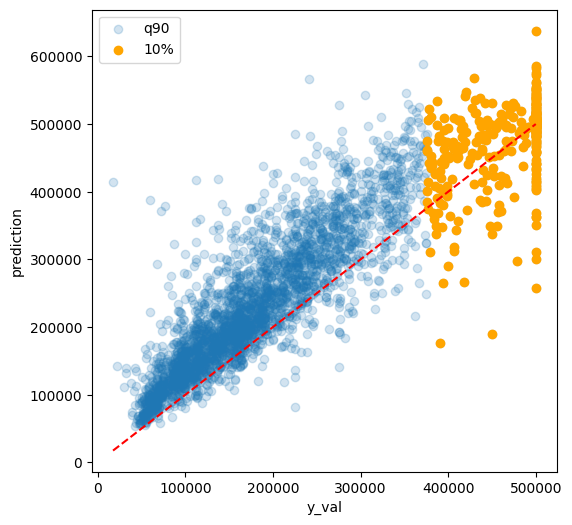

In [102]:
min_y = y_val.min()
max_y = y_val.max()
mask_top10_above_val = y_val >= np.percentile(y_val, 90)

pred_q90full_val = np.expm1(q90_full.predict(X_val))
plt.figure(figsize=(6,6))
plt.scatter(x=y_val,y=pred_q90full_val,alpha=0.2,label='q90')
plt.scatter(x=y_val[mask_top10_above_val],y=pred_q90full_val[mask_top10_above_val],label='10%',color="orange")
plt.plot([min_y, max_y], [min_y, max_y], 'r--')  # đường chuẩn đúng

# plt.xlim(min_y, max_y)
# plt.ylim(min_y, max_y)

plt.xlabel("y_val")
plt.ylabel("prediction")
plt.legend() #để ra label

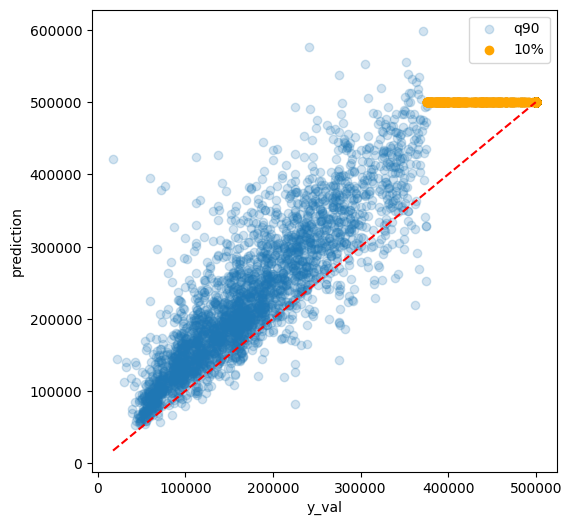

In [109]:
min_y = y_val.min()
max_y = y_val.max()
mask_top10_above_val = y_val >= np.percentile(y_val, 90)

plt.figure(figsize=(6,6))
plt.scatter(x=y_val,y=q90_final,alpha=0.2,label='q90')
plt.scatter(x=y_val[mask_top10_above_val],y=q90_final[mask_top10_above_val],label='10%',color="orange")
plt.plot([min_y, max_y], [min_y, max_y], 'r--')  # đường chuẩn đúng

# plt.xlim(min_y, max_y)
# plt.ylim(min_y, max_y)

plt.xlabel("y_val")
plt.ylabel("prediction")
plt.legend() #để ra label

In [103]:
# # Kiểm tra và tuning tail với val(do outlier tập trung tại q90)
# Tail này do val coverage cắt ra nên cũng phải tầm 90

tail_coverage_val = np.mean(
    y_val[mask_top10_above_val] <= pred_q90full_val[mask_top10_above_val]
)

print(tail_coverage_val)

0.6205787781350482


In [104]:
from sklearn.linear_model import QuantileRegressor

qr = QuantileRegressor(quantile=0.9, alpha=0)
qr.fit(pred_q90full_val.reshape(-1,1), y_val)

pred_q90full_train = np.expm1(q90_full.predict(X_train))
pred_q90full_test = np.expm1(q90_full.predict(X_test))


q90_calibrated_train = qr.predict(pred_q90full_train.reshape(-1,1))
q90_calibrated_val = qr.predict(pred_q90full_val.reshape(-1,1))
q90_calibrated_test = qr.predict(pred_q90full_test.reshape(-1,1))

In [105]:
residual = y_val - q90_calibrated_val
delta = np.quantile(residual, 0.9)

q90_calibrated = q90_calibrated_val + delta
tail_coverage_val = np.mean(
    y_val[mask_top10_above_val] <= q90_calibrated_val[mask_top10_above_val]
)

print(tail_coverage_val)

0.6977491961414791


In [106]:
mask_tail = y_val >= np.percentile(y_val, 90)

qr_tail = QuantileRegressor(quantile=0.9, alpha=0)

qr_tail.fit(
    pred_q90full_val[mask_tail].reshape(-1,1),
    y_val[mask_tail]
)

q90_final = q90_calibrated_val.copy()
q90_final[mask_tail] = qr_tail.predict(
    pred_q90full_val[mask_tail].reshape(-1,1)
)

In [107]:
X_tail = np.hstack([
    X_val[mask_tail],
    pred_q90full_val[mask_tail].reshape(-1,1)
])

qr_tail.fit(X_tail, y_val[mask_tail])

X_tail_pred = np.hstack([
    X_val[mask_tail],
    pred_q90full_val[mask_tail].reshape(-1,1)
])
q90_final = q90_calibrated_val.copy()

q90_final[mask_tail] = qr_tail.predict(X_tail_pred)

In [108]:
# residual = y_val - q90_cal2
# delta = np.quantile(residual, 0.9)
# q90_final = q90_cal2 + delta

In [93]:
tail_coverage_val = np.mean(
    y_val[mask_top10_above_val] <= q90_final[mask_top10_above_val]
)

print(tail_coverage_val)

1.0


In [94]:
coverage_all = np.mean(y_val <= pred_q90full_val)
coverage_tail = np.mean(
    y_val[mask_tail] <= pred_q90full_val[mask_tail]
)

print(coverage_all, coverage_tail)

0.8856589147286822 0.6205787781350482


In [95]:
# from sklearn.isotonic import IsotonicRegression

# iso = IsotonicRegression(out_of_bounds="clip")
# iso.fit(pred_q90full_val, y_val)

# q90_calibrated = iso.predict(pred_q90full_val)

In [97]:
# Check calibrate
coverage_val = np.mean(y_val <= q90_calibrated_val)
print(coverage_val)
tail_coverage_val_calibrated = np.mean(
    y_val[mask_top10_above_val] <= q90_final[mask_top10_above_val]
)
tail_coverage_val_calibrated

0.9001937984496124


np.float64(1.0)

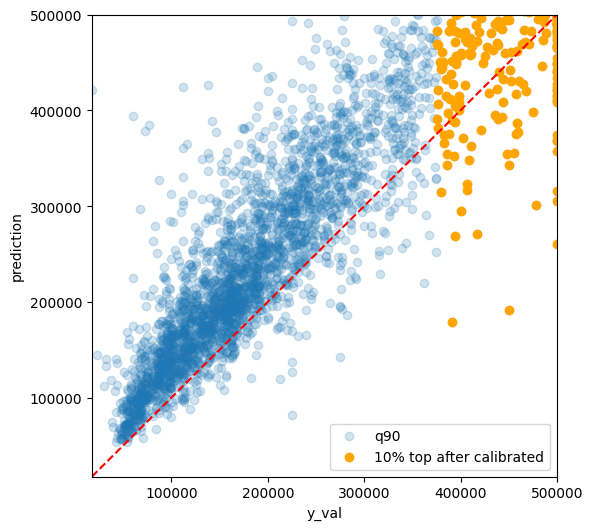

In [63]:
plt.figure(figsize=(6,6))
plt.scatter(x=y_val,y=q90_calibrated_val,alpha=0.2,label='q90')
plt.scatter(x=y_val[mask_top10_above_val],y=q90_calibrated_val[mask_top10_above_val],label='10% top after calibrated',color="orange")
plt.plot([min_y, max_y], [min_y, max_y], 'r--')  # đường chuẩn đúng

plt.xlim(min_y, max_y)
plt.ylim(min_y, max_y)

plt.xlabel("y_val")
plt.ylabel("prediction")
plt.legend()

In [64]:
tail_thr = np.percentile(y_train,90)

is_tail_train = (y_train >= tail_thr)
is_tail_val = (y_val >= tail_thr)

In [ ]:
gate_X_train = np.columnstack([
    q10_train,
    q50_train,
    q90_calibr

In [98]:
# Kiểm tra tail (outlier tập trung ở q90)
mask_top10_above_test = y_test >= np.percentile(y_test, 90)

coverage_full = np.mean(
    y_test[mask_top10_above_test] <= q90_calibrated[mask_top10_above_test]
)

print(coverage_full)
# 2 hướng 1 tail, 2 calibrate
# quantile miscalibration ở tail sau lần thử với gate(threshold=0.

0.11290322580645161


In [153]:
tail_thr = np.percentile(y_train, 90)

In [ ]:
# Vẽ biểu đồ với tập val để tuning tail cao lên với calib
mask_q90 = y_tail <= y_train.quantile(0.9)

plt.scatter(y_train, oof_pred_q10, alpha=0.2,

In [488]:
# # => Làm việc với Kfold khiến hàm train có thể ⭐tái sử dụng để train model ở tầng sau mà <=> không leak
# # Lộn xộn trong tổng số dòng data và trong index

# #⭐ Chia làm K model, ở đây là 5 và khi dự đoán, output ghi lại chưa bao giờ nhìn thấy y, 5 lần như vậy và nó không bị leak => có thể dùng lại X_train

# kf = KFold(n_splits=5, shuffle=True, random_state=42)
# # Shuffle không bị ảnh hưởng tới index gate
# pred_q90_tr = np.zeros(len(X_train))

# # tạo mảng 0 có kích thước:
# for train_idx, fval_idx in kf.split(X_train): #split trả về cho train và val(1 fold để đánh giá), split là hàm của kf không được hiểu như py
#     # train_idx là 1 mảng các vị trí (là chữ số)
#     # loc cần nhập chữ (tên cột)
#     X_tr, X_fold_val = X_train.iloc[train_idx], X_train.iloc[fval_idx] # 4 phần học và 1 phần kiểm tra
#     y_tr, y_fold_val = y_train_log.iloc[train_idx], y_train.iloc[fval_idx] # chia y_train thành 4 phần nhỏ và 1 phần kiểm tra như trên
#     # ⭐ đang sử dụng y log
#     # w_tr = w[train_idx] # <===

#     q90_fold = CatBoostRegressor(
#         depth= 5, #loss
#         iterations= 812, # coverage 
#         l2_leaf_reg= 15, #coverage
#         learning_rate= 0.05904923505296674, #loss
#         random_strength= 1.0094325705132254,
#         loss_function="Quantile:alpha=0.9",
#         subsample= 0.907779386867091,
#         verbose=False
#         )
#     q90_fold.fit(X_tr,
#                 y_tr)
#                 # sample_weight=w_tr)
#     # pred_q90_val = np.zeros(len(X_train))
#     pred_q90_tr[fval_idx] = q90_fold.predict(X_fold_val)
# pred_q90_tr = np.expm1(pred_q90_tr)


# pred_q90_tr
    
# # ⭐ Tất cả đều trong vòng for để fill hết oof_predict

# # q90.fit(X_train,y_train_log,
# #         sample_weight = w_tr,
# #         # eval_set=(x_val,y_val),
# #         # early_stopping_rounds=100000,
# #         # verbose=100,
# #         # use_best_model=True
# #        )

In [500]:
# # Đánh giá fold model
# pinball_q90fold = mean_pinball_loss(y_train, pred_q90_tr, alpha=0.9)/np.mean(y_train)
# coverage_q90fold = np.mean(y_train <= pred_q90_tr)
# print("q90_fold loss:",pinball_q90fold)
# print("q90_fold coverage:",coverage_q90fold)

# # y_val ổn vẫn có thể tuning
# # pred_gate_val  = gate.predict(X_gate_val)

In [39]:
# mask_top10_up = y_val >= np.percentile(y_val, 90)
# np.mean(y_val[mask_top10_up] <= pred_q90full_val[mask_top10_up])

# list_q90 = {
#     'q90': pred_q90_test[mask_top10_up],
#     'y_test':y_test[mask_top10_up]
# }
# pd.DataFrame(list_q90).to_csv('list_q90.csv', index=False)

In [40]:
# # cột input và kết quả nhưng là predict của fold gộp lại xác định tail hay không
# p90 = np.percentile(y_train_log, 90)
# X_gate_train = np.column_stack([X_train,pred_q90_tr])
# y_gate_train = (y_train_log>= p90).astype(int)

# pred_q90full_val = np.expm1(q90_full.predict(X_gate_val)) #⭐⭐
# X_gate_val = np.column_stack([X_gate_val,pred_q90full_val])
# y_gate_val = (y_gate_val_log >= p90).astype(int)

In [499]:
# from catboost import CatBoostClassifier

# gate = CatBoostClassifier(
#     loss_function="Logloss",
#     eval_metric="AUC",
#     verbose=False
# )

# gate_param = {
#     "depth": (3,6),
#     "learning_rate":(0.3,0.1), # log thử các param trên trục log, nhìn chung 2 cách thử khác nhau
#     "l2_leaf_reg":(1,15),
#     'subsample': (0.6, 1.0),
#     'random_strength': (0.1, 10.0),
#     "iterations":(200,2000)
# }
# search = RandomizedSearchCV(
#     gate,
#     gate_param,
#     n_iter=15,
#     scoring="roc_auc",
#     cv=3,
#     n_jobs=-1
# )

# search.fit(X_gate_train, y_gate_train,
#             eval_set=[(X_gate_train, y_gate_train)],   
#     early_stopping_rounds=100
# )


# best_gate = search.best_params_

# print(
#     "gate = CatBoostClassifier(\n" +
#     ",\n".join([f"    {k}={repr(v)}" for k, v in best_gate.items()]) +
#     "\n)"
# )




In [498]:
# # gate = CatBoostClassifier(
# #     iterations = 500, #CM
# #     depth = 6, #AUC, CM
# #     learning_rate= 0.5, # AUC ,
# #     l2_leaf_reg = 10,
# #     loss_function = "Logloss",
# #     eval_metric="PRAUC",
# #     verbose=False
# # )
# gate = CatBoostClassifier(
#     subsample=1.0,
#     random_strength=10.0,
#     learning_rate=0.1,
#     l2_leaf_reg=15,
#     iterations=283,
#     depth=6,
#     # class_weights=[1.0, 1.0],
#     loss_function = "Logloss",
#     eval_metric="AUC",
#     od_type="IncToDec",
#     od_wait=50,
#     verbose=50
# )

# gate.fit(X_gate_train, y_gate_train,
#         eval_set=(X_gate_val,y_gate_val)
#         )

In [86]:
# help(CatBoostClassifier)
# p_cal

In [497]:
# # ROC-AUC đánh giá chất lượng model tổng thế 
# gate_prob_val = gate.predict_proba(X_gate_val)[:,1] #⭐⭐ gồm 2 cột 0 và 1
# print("AUC:", roc_auc_score(y_gate_val,gate_prob_val))
# # AUC thông thường là sẽ quét 1 lượt tất cả các cặp có thể tạo được từ 2 tập hợp và tỉ lệ để cặp 1 lớn hơn 2, trong đó 2 cặp cần có thứ tự cố định.
# # sklearn sắp xếp từ lớn đến nhỏ, quét threshold tính tính ra các điểm của hình thang, tính diện tích ra =>AUC
# # threshold True/False Positive Rate 
# # Kết quả do phần trên chọn cột 1 hay cột không

In [476]:
# threshold = 0.001 #0.03 #0.02 #0.014 # ảnh hưởng lớn => tail coverage tuning cái này có thể để lại khi tuning với tail => tăng cover
# # tail model đang tệ
# is_tail_val = gate_prob_val>= threshold
# # for t in [0.01, 0.014, 0.02, 0.05, 0.1]:
# #     is_tail_val = gate_prob_val>= t
# #     cm_test = confusion_matrix(y_gate_val,is_tail_val,normalize = 'true')
# #     print(f"Confusion matrix val(threshold= {t}):")
# #     print(cm_test)
# #     TN, FP, FN, TP = confusion_matrix(y_gate_val, is_tail_val,normalize = 'true').ravel()
# #     print("FP+FN=",FP+FN)

In [496]:
# gate_prob_train = gate.predict_proba(X_gate_train)
# gate_prob_train

In [478]:
# pred_gate_train = gate.predict(X_gate_train)
# pred_gate_val = gate.predict(X_gate_val)

In [495]:
# # Confusion matrix chỉ sinh ra sau khi ép nó thành nhãn cứng 0/1
# cm_train = confusion_matrix(y_gate_train,pred_gate_train)
# print("Confusion matrix train:")
# print(cm_train) 

# cm_default = confusion_matrix(y_gate_val,pred_gate_val,normalize = 'true')
# print("Confusion matrix val(threshold= 0.5):")
# print(cm_default)

# cm_test = confusion_matrix(y_gate_val,is_tail_val,normalize = 'true')
# print(f"Confusion matrix val(threshold= {threshold}):")
# print(cm_test)

# TN, FP, FN, TP = confusion_matrix(y_gate_val, is_tail_val,normalize = 'true').ravel()
# print("FP+FN=",FP+FN)

# # TN FP
# # FN TP 

# # TN FP lấy thừa trong set đúng
# #    | Precision
# # FN:lấy thiếu trong set đúng - TP
# #  recall
# # Vừa false 
# # FP thấp
# # ⭐Chỉ đường chéo chính là giá trị T phụ là F cần giảm
# # FP = FN luôn làm model có cover tốt hơn

In [480]:
# # Lọc mẫu train qua gate
# gate_prob_train = gate.predict_proba(X_gate_train)[:,1] #trả về tỷ lệ 50 50 2 giá trị
# # trên gate_prob_val đã lấy cột 1 rồi nên thứ tự không bị nhầm
# is_tail_train = gate_prob_train>= threshold
# # Lấy giá trị true từ list 
# X_tail_train = X_train[is_tail_train]
# y_tail_train = y_train[is_tail_train]
# y_tail_train_log = y_train_log[is_tail_train]

In [494]:
# y_tail_val_log

In [482]:
# # Lọc mẫu tail val qua gate
# pred_q90_full_tail = q90_full.predict(X_tail_val)
# X_gate_tail_val= np.column_stack([X_tail_val,pred_q90_full_tail])
# gate_prob_tail_val = gate.predict_proba(X_gate_tail_val)[:,1] #trả về tỷ lệ 50 50 2 giá trị
# # trên gate_prob_val đã lấy cột 1 rồi nên thứ tự không bị nhầm

# # Từ bước này không làm gì với columnstack nữa
# is_tail_val = gate_prob_tail_val>= threshold
# # Lấy giá trị true từ list 
# X_tail_val_a_gate = X_tail_val[is_tail_val]
# y_tail_val_a_gate = y_tail_val[is_tail_val]
# y_tail_val_log_a_gate = y_tail_val_log[is_tail_val]
# # X_tail_val_a_gate.reset_index(inplace=True,drop=True)
# # y_tail_val_a_gate.reset_index(inplace=True,drop=True)
# # y_tail_val_log_a_gate.reset_index(inplace=True,drop=True)
# # after

In [483]:
# # Cho X_test qua gate
# pred_q90full_test= np.expm1(q90_full.predict(X_test))
# pred_q90full_test
# X_gate_test = np.column_stack([X_test,pred_q90full_test])
# y_gate_test = (y_test_log >= p90).astype(int)

# gate_prob_test = gate.predict_proba(X_gate_test)[:,1] #trả về tỷ lệ 50 50 2 giá trị
# # trên gate_prob_val đã lấy cột 1 trong 2 cột 0 và 1, nên thứ tự không bị nhầm
# is_tail_test = gate_prob_test>= threshold
# X_tail_test = X_test[is_tail_test]
# y_tail_test = y_test[is_tail_test]
# y_tail_test_log = y_test_log[is_tail_test]

In [484]:
# alpha = 0.9

# # Model base - mô hình dò, kèm theo tham số cố định

# cat = CatBoostRegressor(
#     loss_function=f'Quantile:alpha={alpha}',
#     verbose=0,
#     random_state=42,
#     allow_writing_files=False
# )
# # Tạo khoảng param tìm tron
# # Không nên để iterations quá rộng
# param_space = {
#     'depth': (3, 8),
#     'learning_rate': (0.01, 0.15, 'log-uniform'),
#     'l2_leaf_reg': (15, 5000),
#     'iterations': (500, 2000),  # giảm range
#     'subsample': (0.6, 1.0),
#     'random_strength': (0.1, 10.0, 'log-uniform')
# }

# # Pinball scorer (BayesSearch sẽ maximize -> phải để negative)
# pinball_scorer = make_scorer(
#     mean_pinball_loss,
#     alpha=alpha,
#     greater_is_better=False
# )

# cv = KFold(n_splits=3, shuffle=True, random_state=42)

# bayes_search = BayesSearchCV(
#     estimator=cat,
#     search_spaces=param_space,
#     n_iter=40,  
#     cv=cv,
#     scoring=pinball_scorer,
#     random_state=42,
#     n_jobs=-1,
#     refit=True
# )


# # bayes_search.fit(
# #     X_train,
# #     y_train,
# #     eval_set=[(X_tail_train,
# #              y_tail_train_log)],   
# #     early_stopping_rounds=100
# # )

# # bayes_search.fit(X_tail_train,
# #              y_tail_train_log,) #⭐⭐⭐⭐⭐⭐

# # best_params = bayes_search.best_params_

# # print(
# #     "q90_tail = CatBoostRegressor(\n" +
# #     ",\n".join([f"    {k}={repr(v)}" for k, v in best_params.items()]) +
# #     "\n)"
# # )

#         # depth=3,
#         # iterations=1727,
#         # l2_leaf_reg=3710,
#         # learning_rate=0.019924114901703784,
#         # random_strength=1.4365762176299859,
#         # subsample=0.709885939534167,

In [493]:
# # q90_tail = CatBoostRegressor(
# #         depth= 3, #loss
# #         iterations= 250, # coverage 
# #         l2_leaf_reg= 5000, #coverage
# #         learning_rate= 0.03, #loss
# #         random_strength= 0.7601845608583428,
# #         loss_function="Quantile:alpha=0.9",
# #         subsample= 0.8075634815109746,
# #         verbose=False
# #         )

# q90_tail = CatBoostRegressor(
#         depth=3,
#         iterations=1727,
#         l2_leaf_reg=3710,
#         learning_rate=0.019924114901703784,
#         random_strength=1.4365762176299859,
#         subsample=0.709885939534167,
#         loss_function="Quantile:alpha=0.9",
#         eval_metric="Quantile:alpha=0.9",
#         od_type="IncToDec",
#         od_wait=50,
#         verbose=False
#         )
# q90_tail.fit(X_tail_train,
#              y_tail_train_log,
#             eval_set= (X_tail_val_a_gate,y_tail_val_log_a_gate)
#             )

In [486]:
# print("train tail mean:", np.mean(y_tail_train))
# print("val tail mean:", np.mean(y_tail_val))

# print("train tail p90:", np.percentile(y_tail_train,90))
# print("val tail p90:", np.percentile(y_tail_val,90))
# # ⭐ Cho tail qua gate và xử lý y như cặp train

In [492]:
# eval_quantile_model(q90_tail,0.9,len(X_tail_train),
#                     X_tail_train, y_tail_train,
#                     X_tail_val_a_gate,y_tail_val_a_gate); #;
# # 0.753247 0.014
# #0.490385  0.01

In [423]:
# pred_q90tail_train = np.expm1(q90_tail.predict(X_tail_train))
# # pred_q90tail_test = np.expm1(q90_tail.predict(X_tail_test))

In [424]:
# rel_loss90tail_train = mean_pinball_loss(y_tail_train, pred_q90tail_train) / np.mean(y_tail_train)
# rel_loss90tail_test = mean_pinball_loss(y_tail_test, pred_q90tail_test) / np.mean(y_tail_test)

# print(pd.DataFrame({
#     "q90_tail train loss:": rel_loss90tail_train,
#     "q90_tail test loss:": rel_loss90tail_test,
#     "relative gap:":cal_rel_gap(rel_loss90tail_test,rel_loss90tail_train)    
# },index=[0]))

In [491]:
# cover90tail_train = np.mean(y_tail_train<=pred_q90tail_train)
# cover90tail_test = np.mean(y_tail_test<=pred_q90tail_test)

# print("q90_tail train coverage:", cover90tail_train)
# print("q90_tail test coverage:", cover90tail_test)

In [490]:
# import matplotlib.pyplot as plt
# import numpy as np

# plt.figure(figsize=(6,6))
# plt.scatter(y_tail_test, pred_q90tail_test, alpha=0.4)

# # đường chuẩn y = x
# min_val = min(y_tail_test.min(), pred_q90tail_test.min())
# max_val = max(y_tail_test.max(), pred_q90tail_test.max())
# plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

# plt.xlabel("y_true (tail)")
# plt.ylabel("y_pred (q90_tail)")
# plt.title("q90_tail: Predicted vs Actual (Tail region)")
# plt.show()
# # 90% dữ liệu nằm dưới =>bám theo cấu trúc của dữ liệu

# # phản ánh được độ phân tán theo độ rộng của điểm đầu và cuối của mây, chiều rộng theo nghĩa đen nếu nhìn mây là hình chữ nhật=> nhìn theo cột OY
# # thì nghĩa là mô hình hiểu được:
# # Ở vùng này rủi ro lớn hơn, độ biến động cao hơn.

# # “Dải mây” cho thấy dự đoán mượt, không bị giật

In [ ]:
# q90_final = np.where(gate_prob_train>= threshold,q90_tail,q90_full)

In [ ]:
# pred_q90tail_train_raw = np.expm1(q90_tail.predict(X_train))
# pred_q90full_train_raw = np.expm1(q90_full.predict(X_train))
# pred_q90tail_test_raw = np.expm1(q90_tail.predict(X_test))
# pred_q90full_test_raw = np.expm1(q90_full.predict(X_test))

In [ ]:
# pred_q90final_train = np.where(
#     gate_prob_train >= threshold,
#     pred_q90tail_train_raw,
#     pred_q90full_train_raw
# )

# pred_q90final_test = np.where(
#     gate_prob_test >= threshold,
#     pred_q90tail_test_raw,
#     pred_q90full_test_raw
# )

In [ ]:
# tail_ratio_train = np.mean(gate_prob_train>= threshold)
# tail_ratio_test = np.mean(gate_prob_test>= threshold)

# print("tail_ratio_train:",tail_ratio_train)
# print("tail_ratio_test:",tail_ratio_test)

In [ ]:
# pred_q90full_train= np.expm1(q90_full.predict(X_train))

# coverage_full_train = np.mean(y_train <= pred_q90full_train)
# print("coverage_full_train:" ,coverage_full_train)

# coverage_full_test = np.mean(y_test <= pred_q90full_test)
# print("coverage_full_test:",coverage_full_test)

In [ ]:
# final_loss_train = mean_pinball_loss(y_train, pred_q90final_train)/np.mean(y_train)
# final_loss_test  = mean_pinball_loss(y_test,  pred_q90final_test)/np.mean(y_train)
# print("final_loss_train:",final_loss_train)
# print("final_loss_test:",final_loss_test)

In [ ]:
# # Kiểm tra xem Mean y (tail zone)  >> Mean y (normal)
# # q90_tail của bạn có cần thiết và có uy tín hay không

# idx_tail = gate_prob_test >= threshold
# print("Mean y (tail zone):", y_test[idx_tail].mean())
# print("Mean y (normal):",   y_test[~idx_tail].mean()) # ~ phủ định của idx tail ngược lại
# print("Mean y (tail zone)  >> Mean y (normal):", y_test[idx_tail].mean() /y_test[~idx_tail].mean())

In [ ]:
# # Đánh giá toàn cục
# coverage_q90_final = np.mean(y_test<= pred_q90final_test)
# coverage_q90_final

In [ ]:
# loss_q90_final_abs = np.mean(np.maximum(
#     0.9*(y_test - pred_q90final_test),
#     0.1*(pred_q90final_test - y_test)
# ))
# loss_q90_final_rel = loss_q90_final_abs / np.mean(y_test)

# print("Quantile loss (absolute):", loss_q90_final_abs)
# print("Quantile loss (relative):", loss_q90_final_rel)

In [ ]:
# loss_q90_final_abs = np.mean(np.maximum(
#     0.9*(y_train - pred_q90final_train),
#     0.1*(pred_q90final_train - y_train)
# ))
# loss_q90_final_rel = loss_q90_final_abs / np.mean(y_train)

# print("Quantile loss (absolute):", loss_q90_final_abs)
# print("Quantile loss (relative):", loss_q90_final_rel)

In [ ]:
# coverage_q90_final_train = np.mean(y_train <= pred_q90final_train)
# coverage_q90_final_test  = np.mean(y_test  <= pred_q90final_test)

# print("Coverage q90 final train:", coverage_q90_final_train)
# print("Coverage q90 final test :", coverage_q90_final_test)

In [ ]:
# # Đánh giá q90_final sau khi có full và tail của q90
# mask_top10 = y_test >= np.percentile(y_test, 90)

# coverage_tail = np.mean(
#     y_test[mask_top10] <= pred_q90tail_test_raw[mask_top10]
# )

# coverage_full = np.mean(
#     y_test[mask_top10] <= pred_q90full_test[mask_top10]
# )

# coverage_final = np.mean(
#     y_test[mask_top10] <= pred_q90final_test[mask_top10]
# )
# print(coverage_tail,coverage_full,coverage_final)
# Cóp tail lên trên có thêm cơ sở ở q90_full

In [489]:
# # Đánh giá và tuning q90full
# eval_quantile_model(q90_full,X_train,X_val, y_train,y_val,alpha= 0.9)

In [ ]:
# print(model_test_result)
# model_train_result.to_csv(r'C:\Users\trieu\OneDrive\Desktop\Dự án\01 Của tôi\PJ1\data\processed\model_train_result.csv')
# model_test_result.to_csv(r'C:\Users\trieu\OneDrive\Desktop\Dự án\01 Của tôi\PJ1\data\processed\model_test_result.csv')


# So sánh với target coverage


# reshape(-1,1) và ravel để đảo lại
# => mỗi file nên import mỗi csv làm đầu vào không nên import cả file
# print((pred_q10_test <= pred_q50_test).mean())
# print((pred_q50_test <= pred_q90_test).mean())

# threshold = np.quantile(uncertainty, 0.9)

# df_test = df.loc[X_test.index].copy()

# df_test['flag_uncertain'] = (uncertainty > pd.Series(uncertainty).quantile(0.9))
# print(df_test['flag_uncertain'].sum() )


In [ ]:
# # AUC- là thang đo ⭐ binary, về khả năng phân biệt bài toán 1
# # Khi có nhiều kết quả hơn 2 thì phải chia ra so sánh 1 1 hoặc 1 và còn lại
# from sklearn.metrics import roc_auc_score, classification_report
# train_prob = roc_auc_score(y_gate_train,gate_prob_train)
# test_prob = roc_auc_score(y_gate_test, gate_prob_test)
# # đo khả năng phân biệt giữa 2 class(có phải tail hay là không)
# # Receiver Operating Characteristic – Area Under the Curve
# c
# print("Test AUC :",test_prob)
# print("Train AUC :",train_prob)

# print(classification_report(y_gate_test, is_tail_test))

In [ ]:
# model_test_result = pd.DataFrame({
#     "y_test": y_test,
#     "pred_q50_test": pred_q50_test,
#     "pred_q10_test": pred_q10_test,
#     "pred_q90_test": pred_q90_test,
# })

# model_train_result = pd.DataFrame({
#     "y_train": y_train,
#     "pred_q50_train": pred_q50_train,
#     "pred_q10_train": pred_q10_train,
#     "pred_q90_train": pred_q90_train,
# })

In [ ]:
# # Coverage - % y thật rơi vào
# # Width - vùng y thật rơi vào

# # Coverage train (debug / check overfit)
# cover10_90_train = np.mean((y_train >= pred_q10_train) & (y_train <= pred_q90_train))
# cover10_50_train = np.mean((y_train >= pred_q10_train) & (y_train <= pred_q50_train))
# cover50_90_train = np.mean((y_train >= pred_q50_train) & (y_train <= pred_q90_train))

# # Coverage trên test (evaluate chính thức)
# # cover10_90_test = np.mean((y_test >= pred_q10_test) & (y_test <= pred_q90_test))
# # cover10_50_test = np.mean((y_test >= pred_q10_test) & (y_test <= pred_q50_test))
# # cover50_90_test = np.mean((y_test >= pred_q50_test) & (y_test <= pred_q90_test))

# # Interval width (train & test)
# width_train = pred_q90_train - pred_q10_train
# width_test  = pred_q90_test - pred_q10_test

# print("Train coverage 10-90:", cover10_90_train, "Width mean:", width_train.mean())
# print("Test coverage 10-90:", cover10_90_test, "Width mean:", width_test.mean())
# print("Width mean gap:",width_train.mean()-width_test.mean())
# print("\nTest coverage 10:", cover10_test, "Train coverage 10:", cover10_train)
# print("Test coverage 50:", cover50_test, "Train coverage 50:", cover50_train)
# print("Test coverage 90:", cover90_test, "Train coverage 90:", cover90_train)

# # Check test-train, test-expextation
# # Cao hơn là overfit, thấp hơn là underfit

In [ ]:
# Hyperparameter tuning
# BGM và NN dùng Bayes
# Nên dùng Py 3.11 trở xuống với catboost

# Sử dụng pruning trong Optuna (dừng sớm các tổ hợp kém).
# !pip install catboost
# !python myscript.py
# !p
# !pip install --upgrade pip
# !pip install catboost scikit-optimize

# Quantile không nên scale y 🔴 Loss phụ thuộc trực tiếp vào đơn vị của y, scale làm méo quantile



# alpha = 0.1
# cat = CatBoostRegressor(
#     loss_function=f'Quantile:alpha={alpha}', # format biểu thức string có thể gán, tìm 1 đoạn string 
#     verbose= 0,
#     random_state = 0
# )
# # CB mặc định dùng RMSE
# param_space = {
#     'depth': (4,8),
#     'learning_rate': (0.01, 0.15, 'log-uniform'), #cách lấy mẫu dàn trải theo log
#     'l2_leaf_reg': (1, 10),
#     'iterations': (500, 2000),
#     # Tham số khống chế overfitting
#     'subsample' : (0.6,1.0),
#     'random_strength': (0.1, 10.0, 'log-uniform')
# }

# pinball_scorer = make_scorer(
#     mean_pinball_loss,
#     alpha=alpha,
#     greater_is_better=False
# )

# bayes_search = BayesSearchCV(
#     estimator = cat,
#     search_spaces = param_space, 
#     n_iter = 25,# số lần thử, tăng để tìm tốt hơn
#     cv = 3,
#     scoring = pinball_scorer, # Để ý những phần liên quan với trên
#     random_state = 42,
#     n_jobs = -1
# )

# bayes_search.fit(X_train, y_train_log)


# (4,10) 4=>10

# residual_0 = y − y_hat_0
# tree_1(x) ≈ residual_0
# y_hat_1 = y_hat_0 + learning_rate × tree_1(x)

# Best parameters: OrderedDict([('depth', 4), ('iterations', 2000), ('l2_leaf_reg', 10), ('learning_rate', 0.038275576007207185), ('random_strength', 0.16620612512184482), ('subsample', 0.8344892090454218)])
# Best CV score: -6349.25306218622

# =>scale hay không không đổi điểm search

# best_params = bayes_search.best_params_

# print(
#     "q10 = CatBoostRegressor(\n" +
#     ",\n".join([f"    {k}={repr(v)}" for k, v in best_params.items()]) +
#     "\n)"
# )

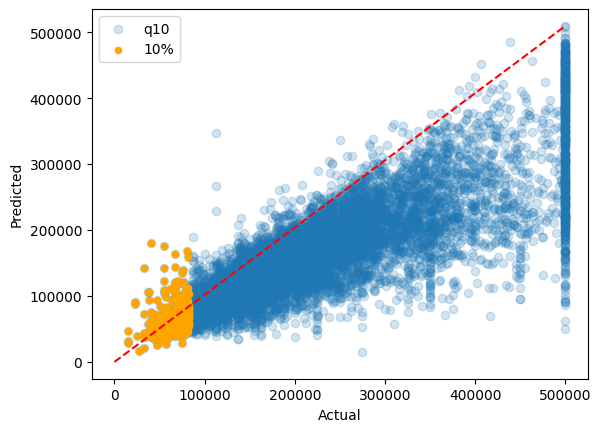

In [28]:
# Để lại ở phần view với test
mask_q10 = y_train <= y_train.quantile(0.1)
plt.scatter(y_train[mask_q10], oof_pred_q10[mask_q10], color='orange', label='10%', s=20)

plt.scatter(y_train, oof_pred_q10, alpha=0.2, label='q10') #alpha là độ mờ

plt.plot([0, max(y_train)], [0, max(oof_pred_q10)], 'r--')
plt.legend()
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

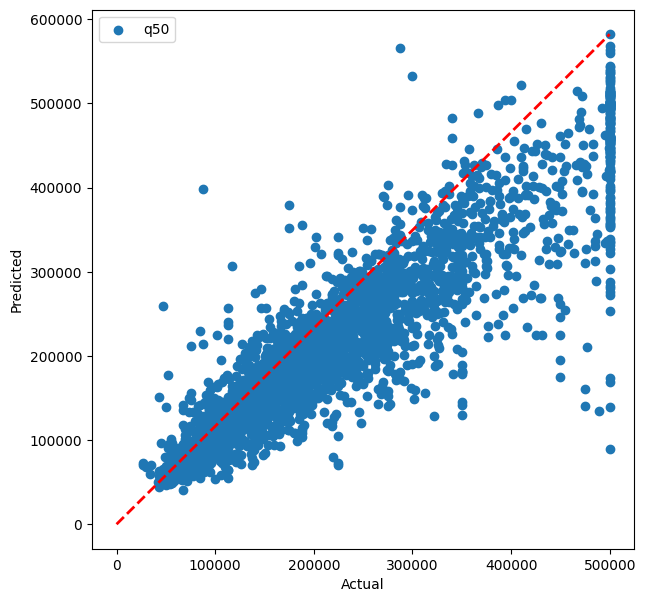

In [38]:
plt.figure(figsize=(7,7))
pred_q50_val= np.expm1(q50.predict(X_val))

plt.scatter(y_val, pred_q50_val, label='q50')

plt.plot([0, max(y_val)], [0, max(pred_q50_val)], 'r--', lw=2)
plt.legend()
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

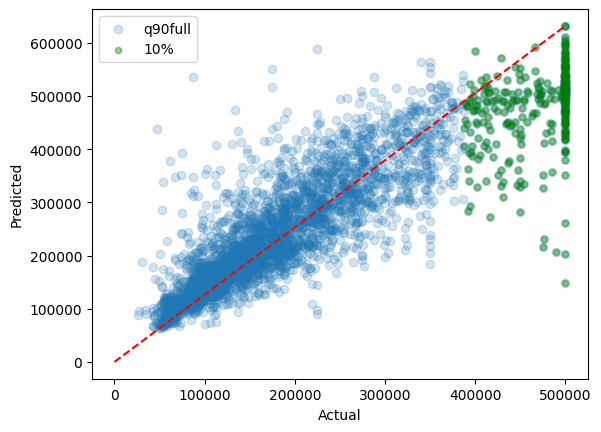

In [36]:
# Tạo mask 10% nhỏ nhất
mask_q90 = y_val >= y_val.quantile(0.9)
pred_q90full_val= np.expm1(q90_full.predict(X_val))

plt.scatter(y_val, pred_q90full_val, alpha=0.2, label='q90full')
plt.scatter(y_val[mask_q90], pred_q90full_val[mask_q90],alpha=0.4, color='green', label='10%', s=20)

plt.plot([0, max(y_val)], [0, max(pred_q90full_val)], 'r--')
plt.legend()
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

In [ ]:
# def eval_quantile_model(model, X_train = None,X_val = None,y ,y_val,alpha): #(model,X_train,X_val,y,y_val,alpha)
#     if X_val =None && X_train=None:
#         rel_loss_val = mean_pinball_loss(y_train, y, alpha = alpha)/np.mean(y_train)
#         val_cover = np.mean(y_val <= y)
#         print(pd.DataFrame({
#             'quantile:': f"{alpha*100}",
#             'val loss': [rel_loss_val],
#             'val_cover:':[val_cover],
#     else:
#         pred_val = np.expm1(model.predict(X_val))
#         pred_train = np.expm1(model.predict(X_train))
#         rel_loss_val = mean_pinball_loss(y_val, pred_val, alpha = alpha)/np.mean(y_val)
#         rel_loss_train = mean_pinball_loss(y, pred_train, alpha = alpha)/ np.mean(y)
#         relative_gap = (rel_loss_val - rel_loss_train)/ train_loss*100
#         train_cover = np.mean(y<= pred_train)
#         val_cover = np.mean(y_val <= pred_val)
#         print(pd.DataFrame({
#             'quantile:': f"{alpha*100}",
#             'val loss': [rel_loss_val],
#             'train loss': [rel_loss_train],
#             'train coverage:':[train_cover],
#             'val_cover:':[val_cover],
#             'relative gap percentage': relative_gap
#     }))

In [ ]:
# Relative Interval Width

In [ ]:
# list_q90 = {
#     'q90': pred_q90_test[mask_top10_up],
#     'y_test':y_test[mask_top10_up]
# }
# pd.DataFrame(list_q90).to_csv('list_q90.csv', index=False)

In [ ]:
# df_check["abs_error"] = abs(df_check["error"])
# df_check.sort_values("abs_error", ascending=False).to_csv('models_error.csv')